In [ ]:
"""
Two circuits, one architecture.

Trains the SAME tiny 2-layer transformer two ways:
  (A) on a copy/repeat task  -> forms an INDUCTION head (offset-diagonal stripe)
  (B) on Dyck-2 bracket text  -> forms a MATCHING head (stack/arc pattern)

Then plots both heads' attention side by side. Only the training data
differs, so the difference in the learned attention is the point.

Run:  python contrast.py
Needs: pip install torch transformer_lens matplotlib
CPU is fine; each model trains in a couple of minutes.
"""


In [3]:
pip install transformer_lens

  Using cached transformer_lens-3.4.0-py3-none-any.whl.metadata (14 kB)
  Using cached better_abc-0.0.3-py3-none-any.whl.metadata (1.4 kB)
  Using cached fancy_einsum-0.0.3-py3-none-any.whl.metadata (1.2 kB)
  Using cached jaxtyping-0.3.11-py3-none-any.whl.metadata (6.2 kB)
  Using cached torchvision-0.22.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached transformers-stream-generator-0.0.5.tar.gz (13 kB)
  Preparing metadata (setup.py) ... done
  Using cached wadler_lindig-0.1.7-py3-none-any.whl.metadata (17 kB)
  Using cached torch-2.7.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.5.

In [1]:

import os
import random
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(0)
random.seed(0)
DEVICE = "cpu"


In [2]:
# --- shared architecture ----------------------------------------------------
K = 20                       # repeat length for the induction task
N_CTX = 1 + 2 * K            # = 41 ; Dyck strings use the same length
IND_STEPS = int(os.environ.get("IND_STEPS", 3000))
DYCK_STEPS = int(os.environ.get("DYCK_STEPS", 6000))
BATCH = 64

def make_model(d_vocab):
    cfg = HookedTransformerConfig(
        n_layers=2, d_model=128, n_heads=4, d_head=32,
        n_ctx=N_CTX, d_vocab=d_vocab, act_fn="relu",
        normalization_type="LN", device=DEVICE, seed=0,
    )
    return HookedTransformer(cfg)

def train(model, sampler, steps, tag):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for step in range(steps):
        tokens = sampler(BATCH).to(DEVICE)
        loss = model(tokens, return_type="loss")
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 500 == 0 or step == steps - 1:
            print(f"[{tag}] step {step:5d}  loss {loss.item():.4f}")
    return model


In [3]:
# --- task A: copy / repeat (vocab 0=BOS, 1..V-1 random) ---------------------
V_IND = 30
def induction_sampler(b):
    seq = torch.randint(1, V_IND, (b, K))
    bos = torch.zeros(b, 1, dtype=torch.long)
    return torch.cat([bos, seq, seq], dim=1)        # [BOS, s, s]

In [4]:
# --- task B: Dyck-2 (0=BOS, 1='(' 2=')' 3='[' 4=']') ------------------------
OPEN = {"(": 1, "[": 3}
CLOSE = {"(": 2, "[": 4}
def random_dyck2(L):
    seq, stack = [], []
    for i in range(L):
        gap = (L - i) - len(stack)               # remaining - stack size (always even)
        if len(stack) == 0 or (gap >= 2 and random.random() < 0.5):
            t = "(" if random.random() < 0.5 else "["
            stack.append(t); seq.append(OPEN[t])
        else:
            t = stack.pop(); seq.append(CLOSE[t])
    return seq
def dyck_sampler(b):
    rows = [[0] + random_dyck2(N_CTX - 1) for _ in range(b)]
    return torch.tensor(rows, dtype=torch.long)

def bracket_pairs(row):
    """Return (closer_pos, opener_pos) pairs for a token row (BOS at 0)."""
    pairs, stack = [], []
    for i, t in enumerate(row):
        if t in (1, 3):
            stack.append(i)
        elif t in (2, 4):
            pairs.append((i, stack.pop()))
    return pairs

In [5]:
# --- train both -------------------------------------------------------------
print("Training induction model...")
ind_model = train(make_model(V_IND), induction_sampler, IND_STEPS, "ind")
print("Training Dyck-2 model...")
dyck_model = train(make_model(5), dyck_sampler, DYCK_STEPS, "dyck")

Training induction model...
[ind] step     0  loss 3.6738
[ind] step   500  loss 1.6850
[ind] step  1000  loss 1.6867
[ind] step  1500  loss 1.6854
[ind] step  2000  loss 1.6838
[ind] step  2500  loss 1.6846
[ind] step  2999  loss 1.6846
Training Dyck-2 model...
[dyck] step     0  loss 1.6006
[dyck] step   500  loss 0.9222
[dyck] step  1000  loss 0.8764
[dyck] step  1500  loss 0.8570
[dyck] step  2000  loss 0.8740
[dyck] step  2500  loss 0.8825
[dyck] step  3000  loss 0.9537
[dyck] step  3500  loss 0.8669
[dyck] step  4000  loss 0.8767
[dyck] step  4500  loss 0.8757
[dyck] step  5000  loss 0.8714
[dyck] step  5500  loss 0.8685
[dyck] step  5999  loss 0.8623


In [6]:
# --- find the induction head (offset-diagonal stripe) -----------------------
ind_sample = induction_sampler(1)
with torch.no_grad():
    _, ind_cache = ind_model.run_with_cache(ind_sample)
ind_score = torch.zeros(2, 4)
for layer in range(2):
    p = ind_cache["pattern", layer][0]
    ind_score[layer] = p.diagonal(offset=-(K - 1), dim1=-2, dim2=-1).mean(-1)
iL, iH = divmod(ind_score.argmax().item(), 4)
ind_attn = ind_cache["pattern", iL][0, iH].numpy()
print(f"Induction head: L{iL}H{iH}  score {ind_score.max().item():.3f}")

Induction head: L0H1  score 0.935


In [7]:
# --- find the matching head (attends closer -> its opener) ------------------
dyck_sample = dyck_sampler(1)
pairs = bracket_pairs(dyck_sample[0].tolist())
with torch.no_grad():
    _, dyck_cache = dyck_model.run_with_cache(dyck_sample)
match_score = torch.zeros(2, 4)
for layer in range(2):
    p = dyck_cache["pattern", layer][0]               # [head, q, k]
    s = torch.stack([p[:, c, o] for c, o in pairs], dim=0).mean(0)  # [head]
    match_score[layer] = s
mL, mH = divmod(match_score.argmax().item(), 4)
dyck_attn = dyck_cache["pattern", mL][0, mH].numpy()
print(f"Matching head:  L{mL}H{mH}  score {match_score.max().item():.3f}")

Matching head:  L1H2  score 0.163


Wrote contrast.png


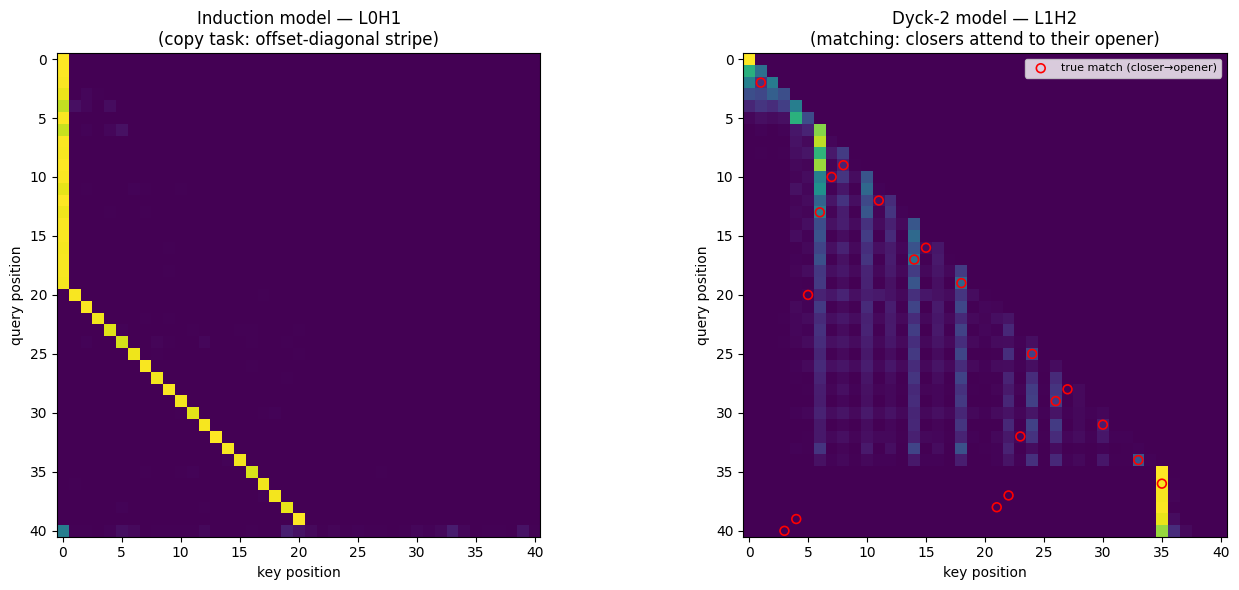

In [8]:
# --- plot side by side ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(ind_attn, cmap="viridis")
axes[0].set_title(f"Induction model — L{iL}H{iH}\n(copy task: offset-diagonal stripe)")
axes[0].set_xlabel("key position"); axes[0].set_ylabel("query position")

axes[1].imshow(dyck_attn, cmap="viridis")
# overlay ground-truth matches: closer (query, y) -> opener (key, x)
xs = [o for _, o in pairs]; ys = [c for c, _ in pairs]
axes[1].scatter(xs, ys, s=40, facecolors="none", edgecolors="red", linewidths=1.2,
                label="true match (closer→opener)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title(f"Dyck-2 model — L{mL}H{mH}\n(matching: closers attend to their opener)")
axes[1].set_xlabel("key position"); axes[1].set_ylabel("query position")

fig.tight_layout()
fig.savefig("contrast.png", dpi=120, bbox_inches="tight")
print("Wrote contrast.png")

In [15]:
import torch.nn.functional as F

# Map token IDs back to characters for display
id_to_char = {0: 'BOS', 1: '(', 2: ')', 3: '[', 4: ']'}

def evaluate_dyck_examples(model, num_examples=10, char_limit=30):
    model.eval()
    samples = dyck_sampler(num_examples).to(DEVICE)

    with torch.no_grad():
        logits = model(samples) # [batch, pos, vocab]
        probs = F.softmax(logits, dim=-1)
        predictions = torch.argmax(probs, dim=-1)

    print(f"{'Input Sequence (Tokens)':<{char_limit}} | {'Correct?'}")
    print("-" * (char_limit + 20))

    for i in range(num_examples):
        tokens = samples[i].tolist()
        preds = predictions[i].tolist()

        # We shift predictions: prediction at index 'j' is for token at 'j+1'
        correct_count = 0
        total_brackets = N_CTX - 1

        for j in range(total_brackets):
            if preds[j] == tokens[j+1]:
                correct_count += 1

        chars = "".join([id_to_char[t] if t != 0 else "B" for t in tokens])
        accuracy = (correct_count / total_brackets) * 100
        # Use the char_limit for slicing the string and padding the print
        print(f"{chars[:char_limit]:<{char_limit}} | {accuracy:.1f}%")

evaluate_dyck_examples(dyck_model, num_examples=10, char_limit=10)

Input Sequence (Tokens) | Correct?
------------------------------
B[]()([((( | 52.5%
B[[]]()[][ | 65.0%
B(([])(()) | 50.0%
B()[][]()[ | 57.5%
B(((()([[] | 50.0%
B()([()[[] | 55.0%
B()[()()[] | 62.5%
B(((([[([] | 50.0%
B[[]]()[]( | 60.0%
B[][()][[[ | 62.5%


In [16]:
dialog_content = r"""# Conversation: Induction vs Dyck-2 Models

**User:** So you're saying that even when the loss plateaus to two decimal places after 500 steps, there are still benefit to going to 3000 steps? What are the benefits?

**Assistant:** Even when the loss appears to have plateaued, there is often a lot happening 'under the hood' in terms of mechanistic interpretability:

1. **Circuit Refinement**: The 'induction circuit' becomes more precise, increasing the induction score even if loss moves slightly.
2. **Weight Stabilization**: Extra steps allow attention patterns to become sharper and higher contrast.
3. **Generalization**: Extra steps help ensure the model has found structural 'logic' rather than just a statistical approximation.

**User:** [Regarding Dyck-2 loss jitter] These losses jump around. What does that tell you, in particular in comparison to the last example?

**Assistant:** The 'jumping around' in Dyck-2 compared to the smooth plateau of Induction tells us:

1. **Task Complexity**: Induction is high-signal (perfect copies), while Dyck-2 is structurally varied.
2. **Structural Variance**: Different sequences have different nesting depths, creating 'sample noise' in batches.
3. **Optimization Landscape**: Induction finds a geometric pattern quickly, whereas Dyck-2 is learning a dynamic 'stack' algorithm.

**User:** How should I interpret the accuracy percents?

**Assistant:** Accuracy in the 50-65% range confirms structural learning:

1. **Baseline**: Random guessing is ~20-25%. 50%+ shows the model knows the rules.
2. **Ambiguity**: The next token isn't always deterministic (it could open OR close), so 100% is impossible, but the model learns the 'forced' tokens (matching the bracket type) perfectly.
"""

with open('dialog.md', 'w') as f:
    f.write(dialog_content)

print('Successfully fixed and wrote dialog.md')"

SyntaxError: unexpected character after line continuation character (3328285602.py, line 1)